In [2]:
# 라이브러리 설정
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
import random

# 랜덤 시드 고정
SEED=12
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

C:\Users\pc\PycharmProjects\fastapi-test\.venv1\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [5]:
train = pd.read_csv("fashionmnist/train.csv")
test = pd.read_csv("fashionmnist/test.csv")

print(train.shape, test.shape)

(60000, 785) (10000, 785)


In [6]:
train.head(3)

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0


In [7]:
test.head(3)

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0


In [11]:
train_images = train.loc[:, "pixel1":].values.reshape(-1, 28, 28)
train_images.shape

(60000, 28, 28)

In [12]:
train_images[0][0]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0])

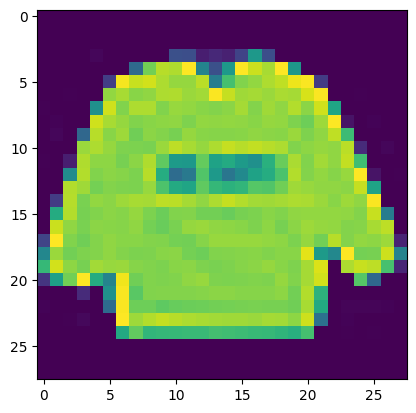

In [14]:
import matplotlib.pyplot as plt
plt.imshow(train_images[0])

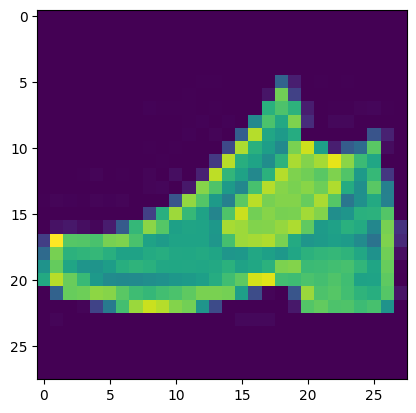

In [15]:
plt.imshow(train_images[1])

In [16]:
y_train = train.loc[:, 'label']
y_train

0        2
1        9
2        6
3        0
4        3
        ..
59995    9
59996    1
59997    8
59998    8
59999    7
Name: label, Length: 60000, dtype: int64

In [17]:
y_train.value_counts()

label
2    6000
9    6000
6    6000
0    6000
3    6000
4    6000
5    6000
8    6000
7    6000
1    6000
Name: count, dtype: int64

In [18]:
y_train.unique()

array([2, 9, 6, 0, 3, 4, 5, 8, 7, 1])

In [19]:
target_values = {0 : 'T-shirt/top',
                 1 : 'Trouser',
                 2: 'Pullover',
                 3: 'Dress',
                 4: 'Coat',
                 5: 'Sandal',
                 6: 'Shirt',
                 7: 'Sneaker',
                 8: 'Bag',
                 9: 'Ankle boot'}

In [20]:
y_train[0]

np.int64(2)

In [21]:
target_values[2]

'Pullover'

In [22]:
target_values[y_train[0]]

'Pullover'

In [23]:
# 읽은 test.csv에 들어있는 첫번째, 두번째 이미지를 화면에 보이고,
# 이름이 무엇인지 프린트해보세요.

In [33]:
test.head(3)

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0


In [51]:
test_images = test.loc[:, "pixel1":].values
test_images.shape

(10000, 784)

In [52]:
test_images = test.loc[:, "pixel1":].values.reshape(-1, 28, 28) # 모양 바꿔줌
test_images.shape

(10000, 28, 28)

In [34]:
test_images[0]  # 한 장의 이미지

array([[  0,   0,   0,   0,   0,   0,   0,   9,   8,   0,   0,  34,  29,
          7,   0,  11,  24,   0,   0,   3,   3,   1,   0,   1,   1,   0,
          0,   0],
       [  0,   0,   4,   0,   0,   1,   0,   0,   0,   0,   0,  44,  88,
         99, 122, 123,  80,   0,   0,   0,   0,   1,   1,   1,   0,   0,
          0,   0],
       [  0,   0,   1,   2,   0,   0,   0,   3,  46, 174, 249,  67,   0,
         94, 210,  61,  14, 212, 157,  37,   0,   0,   0,   0,   1,   0,
          0,   0],
       [  0,   0,   2,   2,   0,  23, 168, 206, 242, 239, 238, 214, 125,
         61, 113,  74, 133, 236, 238, 236, 203, 184,  20,   0,   1,   0,
          0,   0],
       [  0,   0,   1,   0,   0, 175, 245, 223, 207, 205, 206, 216, 255,
        237, 251, 232, 223, 212, 200, 205, 216, 249, 173,   0,   0,   2,
          0,   0],
       [  0,   0,   7,   0,  53, 225, 201, 197, 200, 201, 206, 199, 197,
        185, 194, 204, 232, 226, 249, 219, 194, 205, 229,  33,   0,   1,
          0,   0],
       [  

In [35]:
test_images[0][0]   # 한 장의 이미지에서 첫 줄

array([ 0,  0,  0,  0,  0,  0,  0,  9,  8,  0,  0, 34, 29,  7,  0, 11, 24,
        0,  0,  3,  3,  1,  0,  1,  1,  0,  0,  0])

In [36]:
test_images[0][0][0] # 한 장의 이미지에서  첫 줄의 첫 셀

np.int64(0)

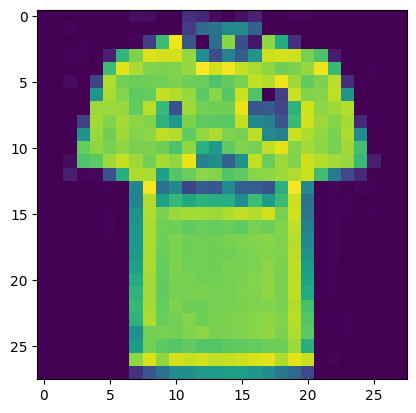

In [25]:
plt.imshow(test_images[0])

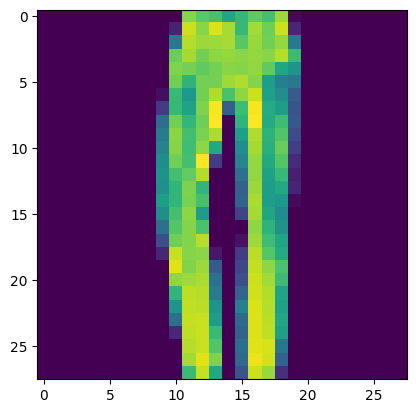

In [26]:
plt.imshow(test_images[1])

In [27]:
y_test = test.loc[:, 'label']
y_test

0       0
1       1
2       2
3       2
4       3
       ..
9995    0
9996    6
9997    8
9998    8
9999    1
Name: label, Length: 10000, dtype: int64

In [29]:
y_test.value_counts()

label
0    1000
1    1000
2    1000
3    1000
8    1000
6    1000
5    1000
4    1000
7    1000
9    1000
Name: count, dtype: int64

In [30]:
y_test.unique()

array([0, 1, 2, 3, 8, 6, 5, 4, 7, 9])

In [31]:
target_values[y_test[0]]

'T-shirt/top'

In [32]:
target_values[y_test[1]]

'Trouser'

In [38]:
## 전처리해서 255 나눠서 스케일링을 합시다.!
## 스케일링 0~255
X_train = train_images / 255
X_test = test_images / 255

print("최소값:", X_train[0].min())
print("최대값:", X_train[0].max())

최소값: 0.0
최대값: 1.0


In [39]:
# 채널 차원 추가(3차원--->4차원으로!)
print("변환 전:", X_train.shape, X_test.shape)

변환 전: (60000, 28, 28) (10000, 28, 28)


In [40]:
## 이미지를 딥러닝처리할 예정이면, 4차원이 되어야함.
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

In [41]:
print("변환 후:", X_train.shape, X_test.shape)

변환 후: (60000, 28, 28, 1) (10000, 28, 28, 1)


In [42]:
# Train - Validation 데이터 구분
from sklearn.model_selection import train_test_split
X_tr, X_val, y_tr, y_val =  train_test_split(X_train, y_train, test_size=0.2,
                                             stratify=y_train,
                                             shuffle=True, random_state=SEED)
print("학습 데이터셋 크기: ", X_tr.shape, y_tr.shape)
print("검증 데이터셋 크기: ", X_val.shape, y_val.shape)

학습 데이터셋 크기:  (48000, 28, 28, 1) (48000,)
검증 데이터셋 크기:  (12000, 28, 28, 1) (12000,)


In [71]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout

In [58]:
mlp_model = Sequential()
# 입력층은 쭉 일렬로 만들어주어야함.
mlp_model.add(Flatten(input_shape=[28, 28]))   # 784
# 은닉층 여러겹
mlp_model.add(Dense(units=64, activation='relu'))
# 64 --> 32 변경 시 예상 효과:
# 파라미터 수 계산 >> 32개의 가중치만 계산에 넣음.
# 784 * 32 ==> 25,120개의 경우의 수를 계싼함.(파라미터 수)
# 학습 속도는 >> 빨라진다.
# 메모리 사용량은 >> 많아진다/적어진다.

# 출력층
mlp_model.add(Dense(units=10, activation='softmax'))

In [59]:
# softmax가 나온 결과치가 손실이 얼마가 되는지(손실함수)
# 이진분류 --> binary cross entropy
# 다중분류 --> categorical cross entropy

In [60]:
# 가중치를 조절해주어 최적화시켜주는 옵티마이저가 필요
# SGD, Adam(**)

In [61]:
# 히스토리
mlp_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['acc'])

In [62]:
mlp_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

In [64]:
# 20번만 읽어서 반복해서 학습하게 하자..epoch(에포크, 주기)
# 이미지 하나씩 읽어서 판단한 다음 손실함수 구해보고, 기울기 조절 반복
# 이미지를 여러개 조금씩 묶어서 판단한 다음 묶은 것의 손실함수를 구해보고,
# 기울기를 조절, 반복이 더 효과적. 64개로 묶을 예정. ==> 750회 읽음.
# 미니배치라고 함.
mlp_history = mlp_model.fit(X_tr, y_tr,
                            batch_size=64,
                            epochs=20,
                            validation_data=(X_val, y_val),
                            verbose=2
                            )

Epoch 1/20
750/750 - 2s - 3ms/step - acc: 0.8583 - loss: 0.4005 - val_acc: 0.8612 - val_loss: 0.3983
Epoch 2/20
750/750 - 1s - 2ms/step - acc: 0.8659 - loss: 0.3747 - val_acc: 0.8660 - val_loss: 0.3823
Epoch 3/20
750/750 - 1s - 2ms/step - acc: 0.8724 - loss: 0.3547 - val_acc: 0.8698 - val_loss: 0.3716
Epoch 4/20
750/750 - 1s - 2ms/step - acc: 0.8777 - loss: 0.3379 - val_acc: 0.8707 - val_loss: 0.3670
Epoch 5/20
750/750 - 1s - 2ms/step - acc: 0.8827 - loss: 0.3238 - val_acc: 0.8732 - val_loss: 0.3597
Epoch 6/20
750/750 - 1s - 2ms/step - acc: 0.8871 - loss: 0.3116 - val_acc: 0.8770 - val_loss: 0.3548
Epoch 7/20
750/750 - 1s - 2ms/step - acc: 0.8907 - loss: 0.3013 - val_acc: 0.8766 - val_loss: 0.3539
Epoch 8/20
750/750 - 1s - 2ms/step - acc: 0.8942 - loss: 0.2905 - val_acc: 0.8770 - val_loss: 0.3523
Epoch 9/20
750/750 - 1s - 2ms/step - acc: 0.8971 - loss: 0.2817 - val_acc: 0.8780 - val_loss: 0.3516
Epoch 10/20
750/750 - 1s - 2ms/step - acc: 0.9002 - loss: 0.2735 - val_acc: 0.8794 - val_lo

In [65]:
mlp_history
## 딥러닝에는 epoch를 수행하면서 특정한 상황이 되면 호출할 수 있는 콜백함수가 많이 정의되어있어서 편함.

In [66]:
mlp_history.history

{'acc': [0.8582500219345093,
  0.8658958077430725,
  0.8723958134651184,
  0.8777291774749756,
  0.8827083110809326,
  0.8870833516120911,
  0.890666663646698,
  0.8941875100135803,
  0.8971041440963745,
  0.9001666903495789,
  0.902999997138977,
  0.9055625200271606,
  0.9078124761581421,
  0.9100208282470703,
  0.9124583601951599,
  0.9146249890327454,
  0.9162083268165588,
  0.9182500243186951,
  0.9200624823570251,
  0.921583354473114],
 'loss': [0.40045109391212463,
  0.37474995851516724,
  0.3546763062477112,
  0.3378695547580719,
  0.3238268494606018,
  0.3116050958633423,
  0.3013371527194977,
  0.29053255915641785,
  0.28167566657066345,
  0.27347660064697266,
  0.2659345865249634,
  0.25876784324645996,
  0.252231240272522,
  0.24614232778549194,
  0.24001875519752502,
  0.23450219631195068,
  0.22898425161838531,
  0.22431591153144836,
  0.21963374316692352,
  0.2145925760269165],
 'val_acc': [0.8611666560173035,
  0.8659999966621399,
  0.8697500228881836,
  0.87066668272018

In [67]:
mlp_history.history.keys()

dict_keys(['acc', 'loss', 'val_acc', 'val_loss'])

In [68]:
mlp_history.history['acc']

[0.8582500219345093,
 0.8658958077430725,
 0.8723958134651184,
 0.8777291774749756,
 0.8827083110809326,
 0.8870833516120911,
 0.890666663646698,
 0.8941875100135803,
 0.8971041440963745,
 0.9001666903495789,
 0.902999997138977,
 0.9055625200271606,
 0.9078124761581421,
 0.9100208282470703,
 0.9124583601951599,
 0.9146249890327454,
 0.9162083268165588,
 0.9182500243186951,
 0.9200624823570251,
 0.921583354473114]

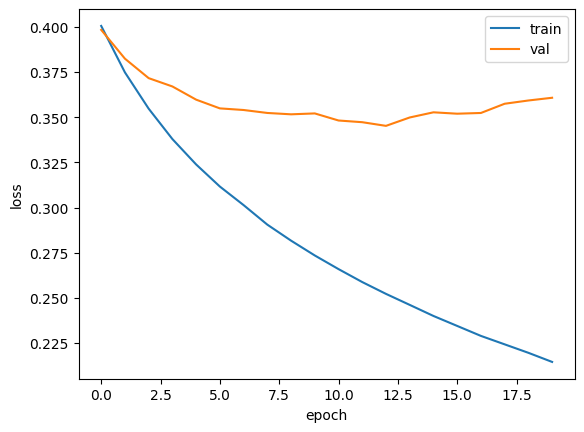

In [69]:
plt.plot(mlp_history.history['loss'])
plt.plot(mlp_history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

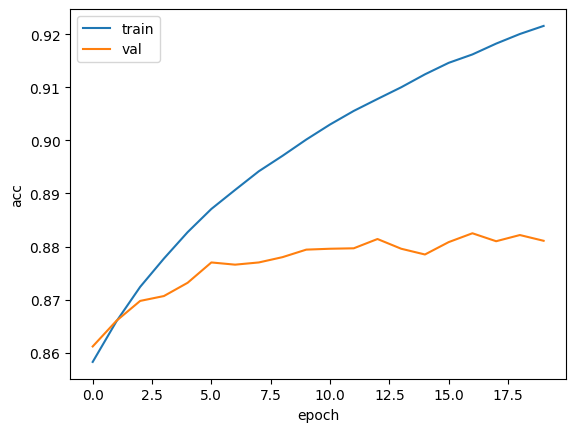

In [70]:
plt.plot(mlp_history.history['acc'])
plt.plot(mlp_history.history['val_acc'])
plt.xlabel('epoch')
plt.ylabel('acc')
plt.legend(['train', 'val'])
plt.show()

In [82]:
mlp2_model = Sequential()
# 입력층은 쭉 일렬로 만들어주어야함.
mlp2_model.add(Flatten(input_shape=[28, 28]))
# 은닉층 여러겹
mlp2_model.add(Dense(units=64, activation='relu'))
mlp2_model.add(Dropout(rate=0.5))
# 출력층
mlp2_model.add(Dense(units=10, activation='softmax'))

In [83]:
mlp2_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['acc'])
mlp2_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

In [84]:
# call-back 2개 지정: 1) 조기 종료, 2) 최적의 가중치 저장
early_stopping = keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
checkpoint = keras.callbacks.ModelCheckpoint('best-mlp2-model.h5')

mlp2_history = mlp2_model.fit(X_tr, y_tr,
                            batch_size=64,
                            epochs=20,
                            validation_data=(X_val, y_val),
                            # callbacks=[가장 좋은 성능일 때 가중치 파일로 저장, 중간 멈춤 기능],
                            callbacks=[checkpoint, early_stopping],
                            verbose=2
                            )

Epoch 1/20


750/750 - 2s - 3ms/step - acc: 0.7292 - loss: 0.7783 - val_acc: 0.8357 - val_loss: 0.4762
Epoch 2/20


750/750 - 1s - 2ms/step - acc: 0.8018 - loss: 0.5551 - val_acc: 0.8479 - val_loss: 0.4272
Epoch 3/20


750/750 - 1s - 2ms/step - acc: 0.8188 - loss: 0.5076 - val_acc: 0.8537 - val_loss: 0.4055
Epoch 4/20


750/750 - 2s - 2ms/step - acc: 0.8239 - loss: 0.4856 - val_acc: 0.8590 - val_loss: 0.3951
Epoch 5/20


...

750/750 - 1s - 2ms/step - acc: 0.8502 - loss: 0.4033 - val_acc: 0.8774 - val_loss: 0.3515
Epoch 17/20


750/750 - 1s - 2ms/step - acc: 0.8504 - loss: 0.4022 - val_acc: 0.8770 - val_loss: 0.3529
Epoch 18/20


750/750 - 1s - 2ms/step - acc: 0.8535 - loss: 0.3947 - val_acc: 0.8760 - val_loss: 0.3561
Epoch 19/20


750/750 - 1s - 2ms/step - acc: 0.8542 - loss: 0.3959 - val_acc: 0.8730 - val_loss: 0.3589
Epoch 20/20


750/750 - 1s - 2ms/step - acc: 0.8574 - loss: 0.3898 - val_acc: 0.8772 - val_loss: 0.3539


In [85]:
mlp2_model.evaluate(X_val, y_val)  # 학습된 결과로 검증해보자.

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - acc: 0.8774 - loss: 0.3515


[0.35150256752967834, 0.8774166703224182]

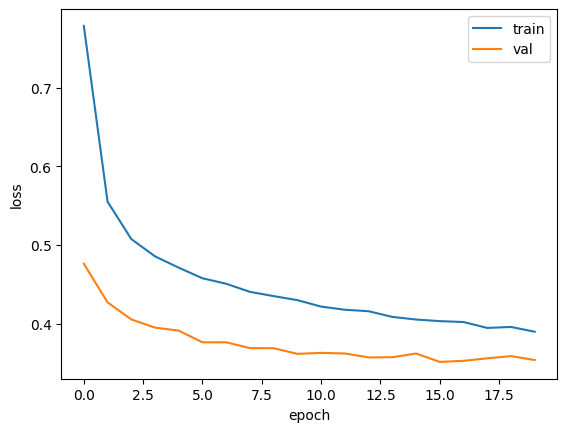

In [86]:
plt.plot(mlp2_history.history['loss'])
plt.plot(mlp2_history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

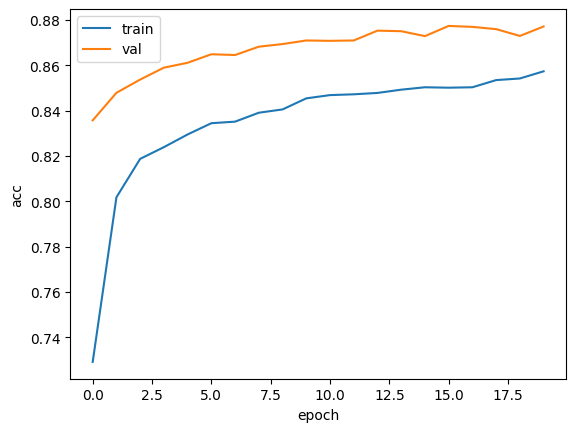

In [87]:
plt.plot(mlp2_history.history['acc'])
plt.plot(mlp2_history.history['val_acc'])
plt.xlabel('epoch')
plt.ylabel('acc')
plt.legend(['train', 'val'])
plt.show()

In [88]:
from tensorflow.keras.models import load_model
best_model = load_model('best-mlp2-model.h5')
best_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,892 (198.80 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [89]:
y_pred_proba = best_model.predict(X_val[0:1])
y_pred_proba

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


array([[1.2418991e-03, 2.1302232e-03, 4.4014725e-01, 3.9628465e-03,
        5.2784741e-01, 9.6112043e-09, 2.2803606e-02, 1.7895276e-11,
        1.8667370e-03, 2.1285070e-12]], dtype=float32)

In [90]:
np.argmax(y_pred_proba) # 리스트의 값 중에서 최고값의 위치를 알려줌.

np.int64(4)

In [92]:
target_values[4]

'Coat'

In [120]:
## 전처리하여 특성을 부여하자....
## 여러가지 이미지의 특성을 자동으로 찾아내고 요약해서 그 결과를 딥러닝에 넣자.
from tensorflow.keras.layers import Conv2D, MaxPooling2D
cnn_model = Sequential()
## 전처리(필터를 거쳐서 특성을 부여한 것을 모은 다음, 요약한다.)
cnn_model.add(Conv2D(filters=16,
                     kernel_size=(3,3),
                     activation='relu',
                     input_shape=[28,28,1]
                     ))
cnn_model.add(MaxPooling2D(pool_size=(2,2)))

In [121]:
## 딥러닝을 시작
# 1차원 데이타로 입력층
#  hidden layer로 층을 쌓고,
#  classification하는 출력층
cnn_model.add(Flatten())
cnn_model.add(Dense(units=64, activation='relu'))
cnn_model.add(Dropout(rate=0.5))
cnn_model.add(Dense(units=10, activation='softmax'))

cnn_model.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics = ['acc']
                 )
cnn_model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 2704)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │       173,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 173,930 (679.41 KB)

 Trainable params: 173,930 (679.41 KB)

 Non-trainable params: 0 (0.00 B)

In [122]:
# call-back 2개 지정: 1) 조기 종료, 최적의 가중치 저장
early_stopping2 = keras.callbacks.EarlyStopping(patience=5,
                                                  restore_best_weights=True)
checkpoint2 = keras.callbacks.ModelCheckpoint('best-cnn2-model.h5')

cnn_history = cnn_model.fit(X_tr, y_tr,
                             batch_size=64,
                             epochs=20,
                             validation_data=(X_val, y_val),
                             callbacks = [ checkpoint2, early_stopping2],
                             verbose=2)

Epoch 1/20


750/750 - 4s - 6ms/step - acc: 0.7510 - loss: 0.7110 - val_acc: 0.8437 - val_loss: 0.4223
Epoch 2/20


750/750 - 3s - 5ms/step - acc: 0.8303 - loss: 0.4859 - val_acc: 0.8752 - val_loss: 0.3513
Epoch 3/20


750/750 - 3s - 5ms/step - acc: 0.8520 - loss: 0.4192 - val_acc: 0.8857 - val_loss: 0.3174
Epoch 4/20


750/750 - 4s - 5ms/step - acc: 0.8622 - loss: 0.3867 - val_acc: 0.8884 - val_loss: 0.3063
Epoch 5/20


...

750/750 - 4s - 5ms/step - acc: 0.9028 - loss: 0.2617 - val_acc: 0.9047 - val_loss: 0.2685
Epoch 15/20


750/750 - 3s - 5ms/step - acc: 0.9062 - loss: 0.2545 - val_acc: 0.9057 - val_loss: 0.2698
Epoch 16/20


750/750 - 3s - 5ms/step - acc: 0.9078 - loss: 0.2456 - val_acc: 0.9066 - val_loss: 0.2688
Epoch 17/20


750/750 - 3s - 5ms/step - acc: 0.9088 - loss: 0.2429 - val_acc: 0.9072 - val_loss: 0.2695
Epoch 18/20


750/750 - 3s - 5ms/step - acc: 0.9086 - loss: 0.2443 - val_acc: 0.9076 - val_loss: 0.2743


In [123]:
## 검증데이터로 검증해보세요.
cnn_model.evaluate(X_val, y_val)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9047 - loss: 0.2663


[0.266299307346344, 0.9047499895095825]

In [124]:
## 모델 파일로 읽어서 요약해보세요.
best_model2 = load_model('best-cnn2-model.h5')
best_model2.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 2704)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │       173,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 173,932 (679.43 KB)

 Trainable params: 173,930 (679.41 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [125]:
best_model2.weights[0]

<Variable path=sequential_8/conv2d_1/kernel, shape=(3, 3, 1, 16), dtype=float32, value=[[[[ 1.23226326e-02  5.89295089e-01  1.67391807e-01  8.38559791e-02
     3.04415345e-01  4.08153623e-01 -3.31227213e-01 -2.99485419e-02
    -4.70223606e-01  5.05216658e-01 -2.39833727e-01  2.54646242e-01
     1.05012685e-01 -1.20975807e-01  5.21384597e-01  3.08649063e-01]]

  [[ 3.73385511e-02 -1.64433792e-02  2.92274147e-01  4.38135862e-02
     2.69831836e-01 -3.26241732e-01 -9.25672576e-02 -1.30016819e-01
    -1.84437007e-01 -6.85694039e-01  3.85071039e-01 -2.89570063e-01
     2.80582249e-01 -6.40599847e-01  5.47923088e-01  2.54127979e-01]]

  [[ 1.21005856e-01 -7.18108058e-01 -1.33803785e-01 -1.25555679e-01
    -5.80069542e-01 -7.70363584e-02  3.71841758e-01  1.95242181e-01
     3.23897898e-01 -1.27025679e-01 -1.81253776e-01 -2.91684687e-01
     3.96474600e-02 -5.38689494e-01  1.14905439e-01 -2.71292686e-01]]]


 [[[-7.71378636e-01 -1.27199814e-01 -2.05327570e-02  1.07948340e-01
     3.67150724e-0

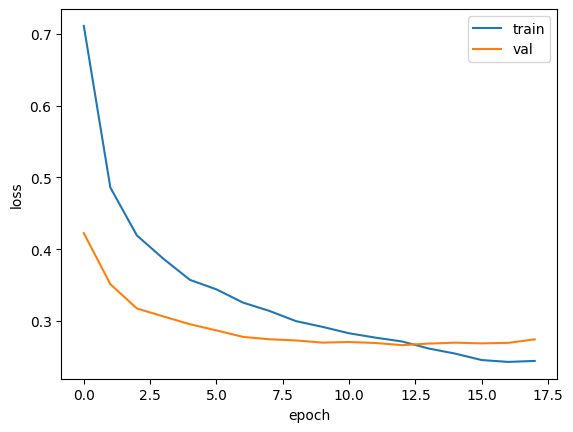

In [126]:
## loss그래프로 그려보세요.
plt.plot(cnn_history.history['loss'])
plt.plot(cnn_history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

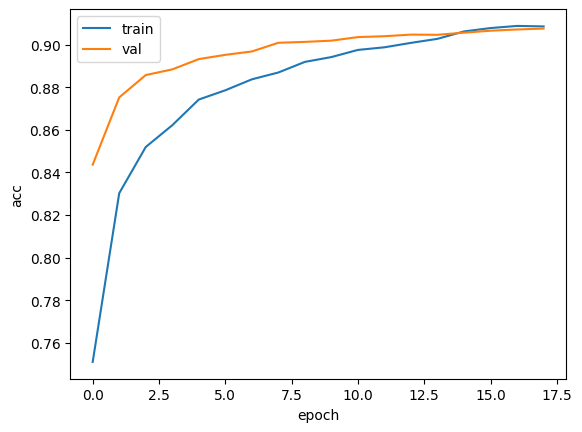

In [127]:
## acc그래프로 그려보세요.
plt.plot(cnn_history.history['acc'])
plt.plot(cnn_history.history['val_acc'])
plt.xlabel('epoch')
plt.ylabel('acc')
plt.legend(['train', 'val'])
plt.show()

In [128]:
y_pred_proba2 = best_model2.predict(X_val[0:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


In [129]:
np.argmax(y_pred_proba2)

np.int64(4)

In [130]:
target_values[4]

'Coat'